# 05 `fmiss` Model Progression

This notebook is the counterexample chapter. It shows that the strategy that works best on `fpos` does not simply transfer to `fmiss`, and that the best `fmiss` path stayed more context-first and more conservative.

Unless otherwise noted, the benchmark tables below report **20 recording-disjoint seeds (`42` to `61`)** and the diagnostics pool the saved holdout predictions across those splits.

**Questions answered here**
- Which `fmiss` modeling path actually worked?
- Why did many `fpos`-inspired tricks fail to transfer?
- How broad were the winning `fmiss` gains across families and recordings?


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

def _find_thesis_root():
    cwd = Path.cwd().resolve()
    direct = [cwd, *cwd.parents]
    nested = [candidate / "thesis" for candidate in direct]
    for candidate in [*direct, *nested]:
        if (
            (candidate / "src" / "qc_thesis" / "__init__.py").exists()
            and (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not find thesis root from notebook session")

ROOT = _find_thesis_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()


def show_saved_figure(path, caption=None):
    figure_path = Path(path)
    if not figure_path.is_absolute():
        figure_path = (ROOT / figure_path).resolve()
    if not figure_path.exists():
        display(Markdown(f"_Missing figure: `{figure_path}`_"))
        return
    if caption:
        display(Markdown(caption))
    display(Image(filename=str(figure_path)))

fig_dir, table_dir = notebook_output_dirs("05_fmiss_model_progression")
benchmark = build_benchmark_progress_table("fmiss", scope="core")
ablation_winners = build_ablation_winner_table("fmiss")
seed_ids = ["fmiss_paired_raw", "fmiss_paired_context", "fmiss_reduced_latent"]
seed_story = build_seed_rank_bundle("fmiss", seed_ids)
wave_ids = ["fmiss_paired_raw", "fmiss_hybrid_only", "fmiss_paired_context", "fmiss_reduced_latent"]
waves = build_main_wave_summary("fmiss", wave_ids)
lofo_family = build_fmiss_lofo_main_family_preference_table()
winner_diag = build_prediction_diagnostics("fmiss_reduced_latent", "fmiss")


## 1. Benchmark ladder

The main-text `fmiss` ladder is also compressed to the core narrative set. The point is not to show every intermediate variant, but to make the central result legible: `fmiss` rewards a more conservative context-first path and does not benefit from transplanting the strongest `fpos` waveform recipe.


In [2]:
display(benchmark[["label", "mae", "rmse", "r2", "bias", "calibration_slope", "delta_r2_vs_basic_transfer", "delta_mae_vs_basic_transfer", "notes"]])
save_table(benchmark, table_dir, "fmiss_benchmark_ladder")
fig, _ = plot_benchmark_metric(benchmark, metric="r2", title="`fmiss` benchmark ladder by R² (20 recording-disjoint seeds)")
save_figure(fig, fig_dir, "fmiss_benchmark_r2")
fig


,label,mae,rmse,r2,bias,calibration_slope,delta_r2_vs_basic_transfer,delta_mae_vs_basic_transfer,notes
0,Dummy paired mean,0.254618,0.290231,-0.083085,0.018784,0.000000,2.128686,-0.135190,Sanity floor
0,Paired-only raw,0.241279,0.309570,-0.234646,-0.028586,0.326243,1.977126,-0.148529,Strict paired-only baseline
0,Hybrid-only XGBoost,0.389808,0.495663,-2.211771,0.326901,0.263252,0.000000,0.000000,Pure source failure baseline
0,Paired-only context,0.214695,0.283785,-0.046193,0.004694,0.569031,2.165579,-0.175113,Context-only target baseline
0,Reduced-latent context,0.210136,0.278649,-0.012812,-0.013671,0.642386,2.198959,-0.179672,Final fmiss reduced-latent context stack


<Figure size 1470x630 with 1 Axes>

In [3]:
fig, _ = plot_benchmark_metric(benchmark, metric="mae", title="`fmiss` benchmark ladder by MAE (20 recording-disjoint seeds)")
save_figure(fig, fig_dir, "fmiss_benchmark_mae")
fig


<Figure size 1470x630 with 1 Axes>

The `fmiss` stability view shows why this target is the weaker transfer story: the central tendency stays much closer to break-even and the split-to-split variance is much larger.

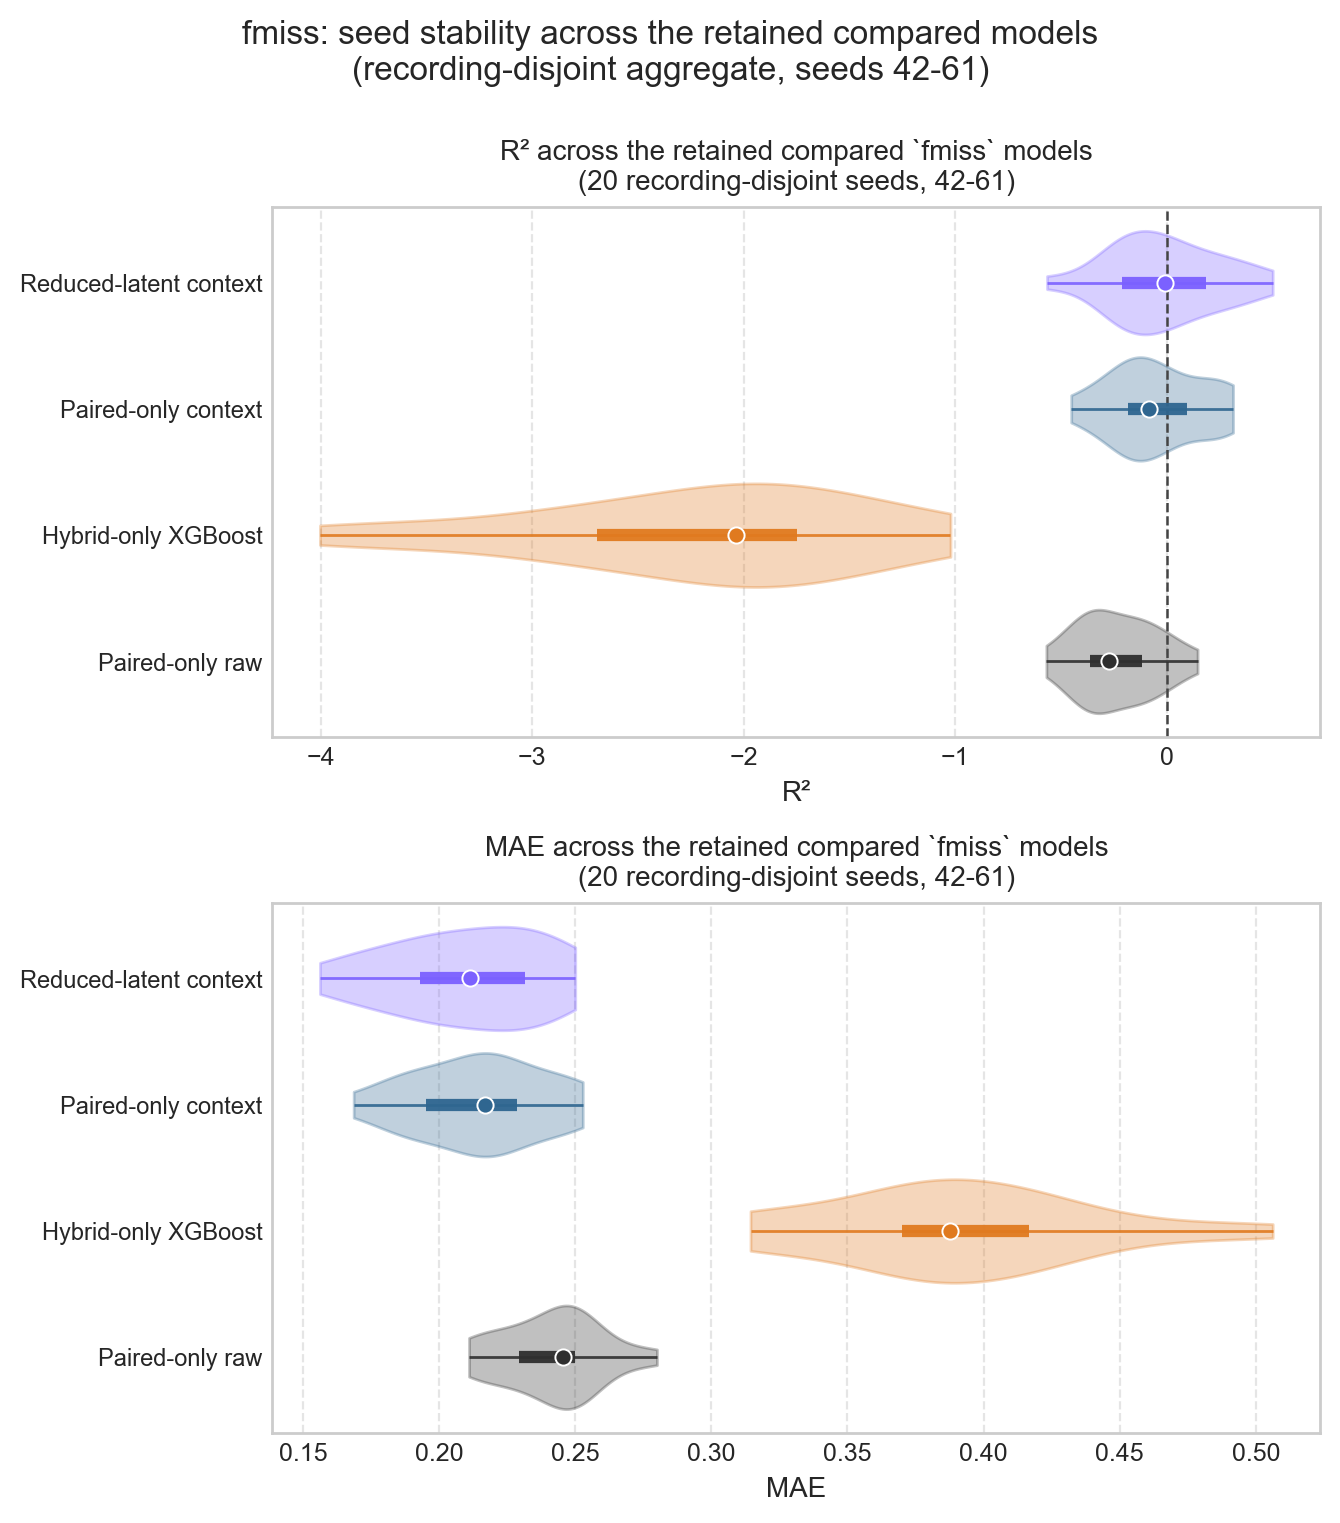

_Missing figure: `/Users/paulruiz/Documents/Predicting_Good_Units/figures/05_fmiss_model_progression/fmiss_seed_rank_heatmap.png`_

In [4]:
show_saved_figure(
    fig_dir / "fmiss_seed_stability.png",
    "The `fmiss` stability view shows why this target is the weaker transfer story: the central tendency stays much closer to break-even and the split-to-split variance is much larger.",
)
show_saved_figure(
    fig_dir / "fmiss_seed_rank_heatmap.png",
    "This rank heatmap complements the violin plot by showing which of the three main compared `fmiss` models actually wins each of the 20 recording-disjoint seeds.",
)


In [5]:
display(seed_story["summary"])
save_table(seed_story["summary"], table_dir, "fmiss_seed_rank_summary")
save_table(seed_story["winner_rows"], table_dir, "fmiss_seed_winner_by_split")


,recipe_id,label,seed_count,mean_r2,std_r2,min_r2,max_r2,mean_mae,std_mae,mean_rank,median_rank,winner_count,top3_count
0,fmiss_reduced_latent,Reduced-latent context,20,-0.012812,0.249552,-0.565056,0.502135,0.210136,0.026733,1.70,1.0,11,20
1,fmiss_paired_context,Paired-only context,20,-0.046193,0.213413,-0.450670,0.314623,0.214695,0.022732,1.75,2.0,5,20
2,fmiss_paired_raw,Paired-only raw,20,-0.234646,0.180923,-0.567979,0.146800,0.241279,0.017510,2.55,3.0,4,20


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/05_fmiss_model_progression/fmiss_seed_winner_by_split.csv')

In [6]:
import matplotlib.pyplot as plt

rank_pivot = seed_story["rank_pivot"].copy()
fig, ax = plt.subplots(figsize=(8.6, 2.9))
im = ax.imshow(rank_pivot.to_numpy(dtype=float), cmap="YlGn_r", vmin=1, vmax=max(len(rank_pivot), 1), aspect="auto")
ax.grid(False)
ax.set_xticks(range(rank_pivot.shape[1]))
ax.set_xticklabels(rank_pivot.columns.astype(str).tolist(), rotation=0)
ax.set_yticks(range(rank_pivot.shape[0]))
ax.set_yticklabels(rank_pivot.index.tolist())
ax.set_xlabel("Recording-disjoint seed")
ax.set_title("Rank by seed across the three main compared `fmiss` models\n(20 recording-disjoint seeds, 42-61; 1 = best `R²`)", pad=10)
for row_idx, row_label in enumerate(rank_pivot.index):
    for col_idx, col_label in enumerate(rank_pivot.columns):
        value = rank_pivot.loc[row_label, col_label]
        if pd.notna(value):
            ax.text(col_idx, row_idx, int(value), ha="center", va="center", fontsize=8)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Rank")
fig.tight_layout()
save_figure(fig, fig_dir, "fmiss_seed_rank_heatmap")
fig


<Figure size 1204x406 with 2 Axes>

In [7]:
winner_row = benchmark.sort_values("r2", ascending=False).iloc[0]
paired_context_row = benchmark.loc[benchmark["recipe_id"] == "fmiss_paired_context"].iloc[0]
hybrid_only_row = benchmark.loc[benchmark["recipe_id"] == "fmiss_hybrid_only"].iloc[0]
display(Markdown(
    f"""
## Main `fmiss` result

- The best `fmiss` row is **{winner_row['label']}** with **R² {winner_row['r2']:.4f}**.
- Compared with the source-only transfer baseline, the retained best row improves from **R² {hybrid_only_row['r2']:.4f}** to **R² {winner_row['r2']:.4f}**.
- Compared with the simpler paired-context model, the reduced-latent stack adds a smaller but still meaningful gain (**R² {paired_context_row['r2']:.4f}** to **{winner_row['r2']:.4f}**).
"""
))



## Main `fmiss` result

- The best `fmiss` row is **Reduced-latent context** with **R² -0.0128**.
- Compared with the source-only transfer baseline, the retained best row improves from **R² -2.2118** to **R² -0.0128**.
- Compared with the simpler paired-context model, the reduced-latent stack adds a smaller but still meaningful gain (**R² -0.0462** to **-0.0128**).


## 2. `fmiss` ablation story

The ablations here are organized around `fmiss`-specific scientific questions: source target choice, context, transfer family, unlabeled paired use, and representation/filtering.


In [8]:
display(ablation_winners)
save_table(ablation_winners, table_dir, "fmiss_ablation_winners")
for group_name in ["source_target_choice", "context", "transfer_family"]:
    bundle = build_ablation_bundle("fmiss", group_name, "recording_disjoint_main")
    display(Markdown(f"### {group_name.replace('_', ' ').title()}"))
    display(bundle["benchmark"][["label", "mae", "r2", "notes"]])
    save_table(bundle["benchmark"], table_dir, f"fmiss_ablation_{group_name}")


,ablation_group,best_label,best_recipe_id,best_r2,best_mae,notes
0,source_target_choice,Dummy paired mean,fmiss_dummy,-0.083085,0.254618,Sanity floor
1,context,Reduced-latent context,fmiss_reduced_latent,-0.012812,0.210136,Final fmiss reduced-latent context stack
2,transfer_family,Reduced-latent context,fmiss_reduced_latent,-0.012812,0.210136,Final fmiss reduced-latent context stack


### Source Target Choice

,label,mae,r2,notes
0,Dummy paired mean,0.257231,-0.003263,Sanity floor
0,Paired-only raw,0.254670,-0.450187,Strict paired-only baseline
0,Hybrid-only XGBoost,0.316161,-1.123877,Pure source failure baseline


### Context

,label,mae,r2,notes
0,Paired-only raw,0.254670,-0.450187,Strict paired-only baseline
0,Paired-only context,0.195047,0.264481,Context-only target baseline
0,Reduced-latent context,0.171945,0.376463,Final fmiss reduced-latent context stack


### Transfer Family

,label,mae,r2,notes
0,Hybrid-only XGBoost,0.316161,-1.123877,Pure source failure baseline
0,Paired-only context,0.195047,0.264481,Context-only target baseline
0,Reduced-latent context,0.171945,0.376463,Final fmiss reduced-latent context stack


## 3. Family-held-out behavior

The stricter `fmiss` family story should be read under leave-one-family-out evaluation rather than ordinary recording-disjoint family averaging. This section keeps the comparison aligned with the retained main compared `fmiss` models: `Paired-only raw`, `Paired-only context`, and `Reduced-latent context`.


In [9]:
display(lofo_family["best"])
display(lofo_family["r2_pivot"])
save_table(lofo_family["best"], table_dir, "fmiss_lofo_family_preference_best")
save_table(lofo_family["r2_pivot"].reset_index(), table_dir, "fmiss_lofo_family_preference_r2")


,held_out_family,best_recipe_id,best_label,best_r2,best_mae,family_rank
0,PAIRED_BOYDEN,fmiss_paired_raw,Paired-only raw,-0.401222,0.246017,1
1,PAIRED_CRCNS_HC1,fmiss_paired_raw,Paired-only raw,-0.299897,0.171787,1
2,PAIRED_ENGLISH,fmiss_paired_context,Paired-only context,-0.650720,0.291745,1
3,PAIRED_KAMPFF,fmiss_paired_raw,Paired-only raw,-0.206854,0.230594,1
4,PAIRED_MEA64C_YGER,fmiss_reduced_latent,Reduced-latent context,0.446192,0.177707,1


label,Paired-only raw,Paired-only context,Reduced-latent context
held_out_family,,,
PAIRED_BOYDEN,-0.401222,-0.895055,-1.033103
PAIRED_CRCNS_HC1,-0.299897,-0.554305,-0.819494
PAIRED_ENGLISH,-0.802932,-0.650720,-0.662508
PAIRED_KAMPFF,-0.206854,-0.859196,-0.797636
PAIRED_MEA64C_YGER,-0.125493,0.187440,0.446192


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/05_fmiss_model_progression/fmiss_lofo_family_preference_r2.csv')

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

family_r2 = lofo_family["r2_pivot"].copy()
fig, ax = plt.subplots(figsize=(7.2, 3.8))
norm = mcolors.TwoSlopeNorm(vmin=-1.10, vcenter=0.0, vmax=0.85)
im = ax.imshow(family_r2.to_numpy(dtype=float), cmap="RdYlGn", norm=norm, aspect="auto")
ax.grid(False)
ax.set_xticks(range(family_r2.shape[1]))
ax.set_xticklabels(family_r2.columns.tolist(), rotation=24, ha="right")
ax.set_yticks(range(family_r2.shape[0]))
ax.set_yticklabels([name.replace("PAIRED_", "") for name in family_r2.index.tolist()])
ax.set_title("Mean held-out-family `R²` across the main compared `fmiss` models\n(20-seed leave-one-family-out aggregate)", pad=10)
for row_idx, family_name in enumerate(family_r2.index):
    for col_idx, label in enumerate(family_r2.columns):
        value = family_r2.loc[family_name, label]
        if pd.notna(value):
            text_color = "white" if abs(value) >= 0.72 else "black"
            ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=8, color=text_color)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Mean R²")
fig.tight_layout()
save_figure(fig, fig_dir, "fmiss_lofo_family_heatmap")
fig


<Figure size 1008x532 with 2 Axes>

### Additional recording-disjoint diagnostics

The plots below remain useful as supporting diagnostics, but the thesis-facing family comparison above is the leave-one-family-out view.


In [11]:
display(waves["family"])
display(waves["recording"].head(20))
save_table(waves["family"], table_dir, "fmiss_family_wave_summary")
save_table(waves["recording"], table_dir, "fmiss_recording_wave_summary")
fig, _, family_pivot = plot_group_metric(waves["family"], group_col="study_set", metric="r2", title="`fmiss` family R² by model wave\n(paired-family summaries from 20 recording-disjoint seeds)")
save_figure(fig, fig_dir, "fmiss_family_r2_by_wave")
save_table(family_pivot, table_dir, "fmiss_family_r2_pivot")
fig


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias,seed_count,row_count_std,mae_std,rmse_std,r2_std,bias_std
0,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN,16.052632,0.285703,0.352052,-3.789239,0.094898,19,6.629072,0.122322,0.108397,7.439605,0.243256
1,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1,12.111111,0.225840,0.261855,-1.176786,0.141281,18,5.248163,0.078593,0.082418,1.653361,0.125393
2,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH,40.100000,0.241829,0.297124,-0.264749,-0.032396,20,10.425450,0.045923,0.051807,0.585746,0.132793
3,fmiss_paired_context,Paired-only context,PAIRED_KAMPFF,16.500000,0.220345,0.281574,-3.735282,0.021121,18,6.184658,0.095783,0.087083,9.826791,0.193415
4,fmiss_paired_context,Paired-only context,PAIRED_MEA64C_YGER,18.900000,0.104882,0.157338,0.626950,0.003807,20,7.105632,0.038808,0.052954,0.224379,0.062236
5,fmiss_reduced_latent,Reduced-latent context,PAIRED_BOYDEN,16.052632,0.285266,0.338368,-3.684517,0.111721,19,6.629072,0.119183,0.110165,7.471207,0.225295
6,fmiss_reduced_latent,Reduced-latent context,PAIRED_CRCNS_HC1,12.111111,0.184270,0.226493,-0.837259,0.095791,18,5.248163,0.090654,0.096960,1.610509,0.123725
7,fmiss_reduced_latent,Reduced-latent context,PAIRED_ENGLISH,40.100000,0.244827,0.295954,-0.245203,-0.058900,20,10.425450,0.051803,0.057731,0.550932,0.146023
8,fmiss_reduced_latent,Reduced-latent context,PAIRED_KAMPFF,16.500000,0.213397,0.280500,-2.135927,0.004868,18,6.184658,0.083514,0.089626,4.224445,0.183257
9,fmiss_reduced_latent,Reduced-latent context,PAIRED_MEA64C_YGER,18.900000,0.091375,0.144176,0.685861,-0.020966,20,7.105632,0.030222,0.047907,0.179179,0.053058


,recipe_id,label,recording_key,row_count,mae,rmse,r2,bias,seed_count,row_count_std,mae_std,rmse_std,r2_std,bias_std
0,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,10.0,0.217787,0.280233,-0.016639,-0.005437,10,0.0,0.066821,0.056032,0.413136,0.139869
1,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::419_1_8,11.0,0.144022,0.192667,0.377004,-0.141462,9,0.0,0.031208,0.045998,0.299341,0.033601
2,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.001,1.0,0.289913,0.289913,NaN,0.289913,12,0.0,0.141872,0.141872,0.000000,0.141872
3,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,8.0,0.247575,0.284906,-2.489449,0.188959,11,0.0,0.109239,0.118641,2.660084,0.142452
4,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_19...,3.0,0.410467,0.430348,-45.866790,-0.410467,12,0.0,0.130968,0.119291,21.998932,0.130968
5,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_22...,7.0,0.287596,0.298029,-2305.744552,0.287596,13,0.0,0.140066,0.137100,1904.929327,0.140066
6,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m14_190326_155432,3.0,0.240910,0.258864,-146.627217,0.223068,14,0.0,0.156277,0.159500,155.697483,0.175076
7,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_142...,6.0,0.188734,0.223196,-0.067228,-0.146611,10,0.0,0.033983,0.038525,0.366342,0.075966
8,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_152...,6.0,0.169485,0.181071,-7.233494,0.156887,10,0.0,0.090123,0.093942,7.930711,0.092705
9,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m26_190524_100...,3.0,0.310417,0.363040,-3.925268,-0.233346,12,0.0,0.094502,0.100152,2.400733,0.176588


<Figure size 1540x630 with 1 Axes>

In [12]:
recording_mean = (
    waves["recording"]
    .groupby(["label", "recording_key"], as_index=False)["r2"]
    .mean()
)
top_rec, bottom_rec = build_extreme_groups_table(recording_mean[recording_mean["label"] == REDUCED_LATENT_CONTEXT_LABEL], group_col="recording_key", metric="r2", top_n=12)
focus_recordings = pd.concat([top_rec, bottom_rec], ignore_index=True)["recording_key"].drop_duplicates().tolist()
recording_focus = waves["recording"][waves["recording"]["recording_key"].isin(focus_recordings)].copy()
display(top_rec)
display(bottom_rec)
save_table(top_rec, table_dir, "fmiss_top_recordings")
save_table(bottom_rec, table_dir, "fmiss_worst_recordings")
fig, _, rec_pivot = plot_group_metric(recording_focus, group_col="recording_key", metric="r2", title="`fmiss` recording R² by model wave\n(top/bottom recordings from 20 recording-disjoint seeds)")
save_figure(fig, fig_dir, "fmiss_top_recording_r2_by_wave")
save_table(rec_pivot, table_dir, "fmiss_recording_r2_pivot")
fig


,label,recording_key,r2
0,Reduced-latent context,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.817676
1,Reduced-latent context,PAIRED_MEA64C_YGER::paired_mea64c::20170621_pa...,0.809171
2,Reduced-latent context,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.689901
3,Reduced-latent context,PAIRED_ENGLISH::paired_english::m57_191105_161455,0.442876
4,Reduced-latent context,PAIRED_BOYDEN::paired_boyden32c::419_1_7,0.347590
5,Reduced-latent context,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.342845
6,Reduced-latent context,PAIRED_MEA64C_YGER::paired_mea64c::20160415_pa...,0.307992
7,Reduced-latent context,PAIRED_ENGLISH::paired_english::m57_191105_141906,0.297976
8,Reduced-latent context,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,0.073641
9,Reduced-latent context,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.002,0.036916


,label,recording_key,r2
0,Reduced-latent context,PAIRED_KAMPFF::paired_kampff::2014_11_25_Pair_3_0,-7306.240875
1,Reduced-latent context,PAIRED_ENGLISH::paired_english::m139_200114_22...,-2107.858088
2,Reduced-latent context,PAIRED_ENGLISH::paired_english::m14_190326_155432,-168.649875
3,Reduced-latent context,PAIRED_ENGLISH::paired_english::m139_200114_19...,-53.700358
4,Reduced-latent context,PAIRED_BOYDEN::paired_boyden32c::509_1_1,-22.684970
5,Reduced-latent context,PAIRED_ENGLISH::paired_english::m57_191105_153915,-18.131798
6,Reduced-latent context,PAIRED_ENGLISH::paired_english::m57_191105_160026,-10.459075
7,Reduced-latent context,PAIRED_ENGLISH::paired_english::m15_190315_150...,-5.350804
8,Reduced-latent context,PAIRED_KAMPFF::paired_kampff::c14,-5.330005
9,Reduced-latent context,PAIRED_ENGLISH::paired_english::m108_191125_17...,-4.275122


<Figure size 1260x1394.4 with 2 Axes>

## 4. Dedicated reduced-latent context stack diagnostics

This is the structural comparison that matters most for the `fmiss` story: the final model still behaves like a conservative context-first correction model rather than a dramatic architecture shift.


In [13]:
context_compare = pd.DataFrame([
    {
        "model": "Paired-only context",
        "r2": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_paired_context", "r2"].iloc[0]),
        "mae": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_paired_context", "mae"].iloc[0]),
    },
    {
        "model": "Reduced-latent context",
        "r2": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_reduced_latent", "r2"].iloc[0]),
        "mae": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_reduced_latent", "mae"].iloc[0]),
    },
])
display(context_compare)
save_table(context_compare, table_dir, "fmiss_context_progress_comparison")
fig, _ = plot_prediction_scatter(winner_diag["predictions"], title="Best `fmiss` model: observed vs predicted")
save_figure(fig, fig_dir, "fmiss_winner_prediction_scatter")
fig


,model,r2,mae
0,Paired-only context,-0.046193,0.214695
1,Reduced-latent context,-0.012812,0.210136


<Figure size 896x868 with 1 Axes>

In [14]:
milestone = pd.DataFrame([
    {"stage": "1  sanity floor", "model": "Dummy paired mean", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_dummy", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_dummy", "mae"].iloc[0])},
    {"stage": "2  paired baseline", "model": "Paired-only raw", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_paired_raw", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_paired_raw", "mae"].iloc[0])},
    {"stage": "3  source transfer", "model": "Hybrid-only XGBoost", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_hybrid_only", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_hybrid_only", "mae"].iloc[0])},
    {"stage": "4  paired context", "model": "Paired-only context", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_paired_context", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_paired_context", "mae"].iloc[0])},
    {"stage": "5  reduced latent", "model": "Reduced-latent context", "r2": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_reduced_latent", "r2"].iloc[0]), "mae": float(benchmark.loc[benchmark["recipe_id"] == "fmiss_reduced_latent", "mae"].iloc[0])},
])
display(milestone)
save_table(milestone, table_dir, "fmiss_milestone_trajectory")


,stage,model,r2,mae
0,1 sanity floor,Dummy paired mean,-0.083085,0.254618
1,2 paired baseline,Paired-only raw,-0.234646,0.241279
2,3 source transfer,Hybrid-only XGBoost,-2.211771,0.389808
3,4 paired context,Paired-only context,-0.046193,0.214695
4,5 reduced latent,Reduced-latent context,-0.012812,0.210136


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/05_fmiss_model_progression/fmiss_milestone_trajectory.csv')

In [15]:
display(Markdown(
    f"""
## Key takeaways

- The best `fmiss` path remained **context-first** and relatively conservative.
- The dedicated reduced-latent context stack reaches correlation **{winner_diag['correlation']:.3f}** on the pooled holdout predictions from the 20 recording-disjoint seeds.
- The main retained gain is incremental rather than dramatic: reduced latent improves on the simpler paired-context model, but `fmiss` remains much harder than `fpos`.
"""
))



## Key takeaways

- The best `fmiss` path remained **context-first** and relatively conservative.
- The dedicated reduced-latent context stack reaches correlation **0.402** on the pooled holdout predictions from the 20 recording-disjoint seeds.
- The main retained gain is incremental rather than dramatic: reduced latent improves on the simpler paired-context model, but `fmiss` remains much harder than `fpos`.
